# Diffraction from Gaussian Beams: Sinusoidal Phase Grating

This notebook demonstrates that Gaussian beams correctly reproduce Bragg diffraction from a sinusoidal phase grating.

The key idea:
1. A sinusoidal phase grating imprints a spatially-varying phase on each Gaussian beam via the Taylor expansion of the sample transmission.
2. The phase gradient at each beam centre deflects the beam and produces a transverse kick.
3. A lens in back-focal-plane geometry converts angles to positions: beams deflected by angle $\theta$ arrive at $x_{\mathrm{BFP}} = f \cdot \theta$.
4. The coherent sum of all beams at the detector plane produces constructive interference at the Bragg angles, giving discrete diffraction spots at $x_n = n \lambda f / d$.

### Convention note

In TemGymCore, `phase_shift(xy)` returns the action coefficient (optical path length in metres),
not the raw phase in radians. The actual phase is $k \times$ `phase_shift`. For `InterpolatedSample2D`,
`phase_shift = angle(T)`, so the input complex transmission must encode the action coefficient:
$$T(x,y) = |A(x,y)| \exp\!\bigl(i\, \phi(x,y) / k\bigr)$$
where $\phi$ is the physical phase in radians.

In [ ]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.3"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.components import (
    Detector,
    Lens,
    Plane,
    sample_interpolant,
)
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_cuda_gpu_kernel_wrapper_opt as evaluate_beams
from temgym_core.plotting import plot_model, PlotParams
from temgym_core.run import run_to_end_vmapped
from temgym_core.source import square_input_wave

jax.config.update("jax_enable_x64", True)
print("JAX backend:", jax.devices()[0].platform)
print("XLA_PYTHON_CLIENT_MEM_FRACTION:", os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"])
print("XLA_PYTHON_CLIENT_PREALLOCATE:", os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"])

JAX backend: gpu
XLA_PYTHON_CLIENT_MEM_FRACTION: 0.02
XLA_PYTHON_CLIENT_PREALLOCATE: false


## Sinusoidal Phase Grating

### 1.1 Set up parameters

We use a sinusoidal phase grating: $T(x, y) = \exp(i \phi_0 \sin(2\pi x / d))$.

For small $\phi_0$, the Fourier expansion gives first-order diffraction spots at angles
$\theta = \pm \lambda/d$, with intensity $\propto J_1^2(\phi_0)$.

In [2]:
# Physical parameters
voltage = 200e3  # 200 kV electron beam
wavelength = float(energy2wavelength(voltage))  # in metres
k = 2 * np.pi / wavelength  # wavevector
print(f"Electron wavelength: {wavelength * 1e12:.2f} pm")
print(f"k = {k:.3e} 1/m")

# Lens
f = 2.3e-3  # 2.3 mm focal length

# Sinusoidal grating
grating_period = 5e-9  # 5 nm period
phase_amplitude = 1.0  # radians (moderate phase object)

Electron wavelength: 2.51 pm
k = 2.505e+12 1/m


### 1.2 Build the sinusoidal sample

The transmission is encoded with the action coefficient $\phi/k$ as the complex argument,
matching the TemGymCore convention where `phase_shift` returns optical path length.

Max physical phase: 1.000 rad
Max optical action: 3.990e-13 m


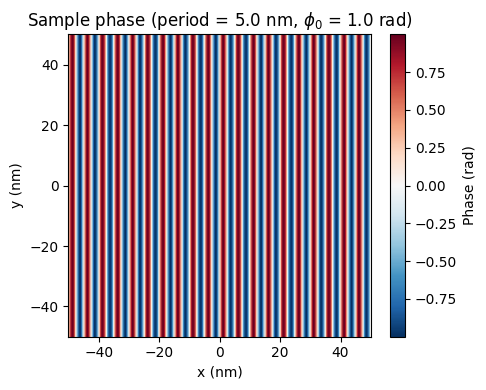

In [3]:
# Discretise the sample on a grid
n_sample = 256
sample_half_width = 50e-9  # 50 nm half-width
x_coords = np.linspace(-sample_half_width, sample_half_width, n_sample)
y_coords = np.linspace(-sample_half_width, sample_half_width, n_sample)
X, Y = np.meshgrid(x_coords, y_coords, indexing="ij")

# Physical phase (radians)
phase_pattern = phase_amplitude * np.sin(2 * np.pi * X / grating_period)

# Encode the optical action coefficient S = phi / k = phi * lambda / (2*pi)
action_pattern = phase_pattern * wavelength / (2 * np.pi)
transmission = np.exp(1j * action_pattern)

sample = sample_interpolant(
    sample=transmission,
    x_coords=x_coords,
    y_coords=y_coords,
    z=0.0,
    method="cubic",
    extrap=1.0,
)

print(f"Max physical phase: {np.abs(phase_pattern).max():.3f} rad")
print(f"Max optical action: {np.abs(action_pattern).max():.3e} m")

# Plot the physical phase
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    phase_pattern.T,
    extent=[x_coords[0] * 1e9, x_coords[-1] * 1e9, y_coords[0] * 1e9, y_coords[-1] * 1e9],
    origin="lower",
    cmap="RdBu_r",
)
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title(f"Sample phase (period = {grating_period*1e9:.1f} nm, $\\phi_0$ = {phase_amplitude} rad)")
plt.colorbar(im, label="Phase (rad)")
plt.tight_layout()

### 1.3 Create the Gaussian beam illumination

A plane-wave illumination decomposed into a grid of Gaussian beamlets covering the sample area.

In [4]:
# Gaussian beam grid: waist < grating period so each beamlet resolves the phase gradient
waist = grating_period / 2
aperture_length = 2 * sample_half_width

rays_in = square_input_wave(
    aperture_length=aperture_length,
    waist=waist,
    voltage=voltage,
    overlap_factor=20.0,
    z0=0.0,
)
n_beams = int(np.asarray(rays_in.x).size)
print(f"Number of Gaussian beams: {n_beams}")

Number of Gaussian beams: 640000


### 1.4 Propagate through sample -> lens -> back focal plane

The geometry is: sample at z=0, lens at z=f, back focal plane at z=2f.
This is the standard 2f Fourier-transform geometry.

In [5]:
lens = Lens(z=f, focal_length=f)
bfp_plane = Plane(z=2 * f)

# Beams through sample
rays_after_sample = run_to_end_vmapped(rays_in, (sample,))

# Through lens to BFP
rays_at_bfp = run_to_end_vmapped(rays_after_sample, (lens, bfp_plane))

# Check the deflection angles are physical
dx_after = np.asarray(rays_after_sample.dx)
max_deflection = phase_amplitude * wavelength / grating_period  # phi0 * lambda/d
print(f"Beam angles after sample: [{dx_after.min():.2e}, {dx_after.max():.2e}] rad")
print(f"Expected max deflection (phi0*lambda/d): {max_deflection:.2e} rad")
print(f"Beam positions at BFP: [{float(rays_at_bfp.x.min()):.2e}, {float(rays_at_bfp.x.max()):.2e}] m")

Beam angles after sample: [-5.10e-04, 5.09e-04] rad
Expected max deflection (phi0*lambda/d): 5.02e-04 rad
Beam positions at BFP: [-1.17e-06, 1.17e-06] m


### 1.5 Evaluate the diffraction pattern at the BFP

Individual beams are deflected by the local phase gradient, spreading to a
continuous range of angles up to $\pm\phi_0\lambda/d$. However, when the beams
are summed **coherently** on the detector, interference concentrates the
intensity into discrete Bragg spots at $x_n = n\lambda f/d$.

In [6]:
# Expected diffraction spot positions
spot_spacing = wavelength * f / grating_period
print(f"Expected 1st-order spot at x = +/-{spot_spacing*1e6:.3f} um")

# Detector at BFP - wide enough to see several orders
bfp_width = 6 * spot_spacing
n_det = 512
pixel_size = 2 * bfp_width / n_det

detector_bfp = Detector(
    z=2 * f,
    pixel_size=(pixel_size, pixel_size),
    shape=(n_det, n_det),
)

field_bfp = evaluate_beams(rays_at_bfp, detector_bfp)
intensity_bfp = jnp.abs(field_bfp) ** 2

print(f"Field has {np.isfinite(np.asarray(field_bfp)).mean():.0%} finite values")

Expected 1st-order spot at x = +/-1.154 um
Field has 100% finite values


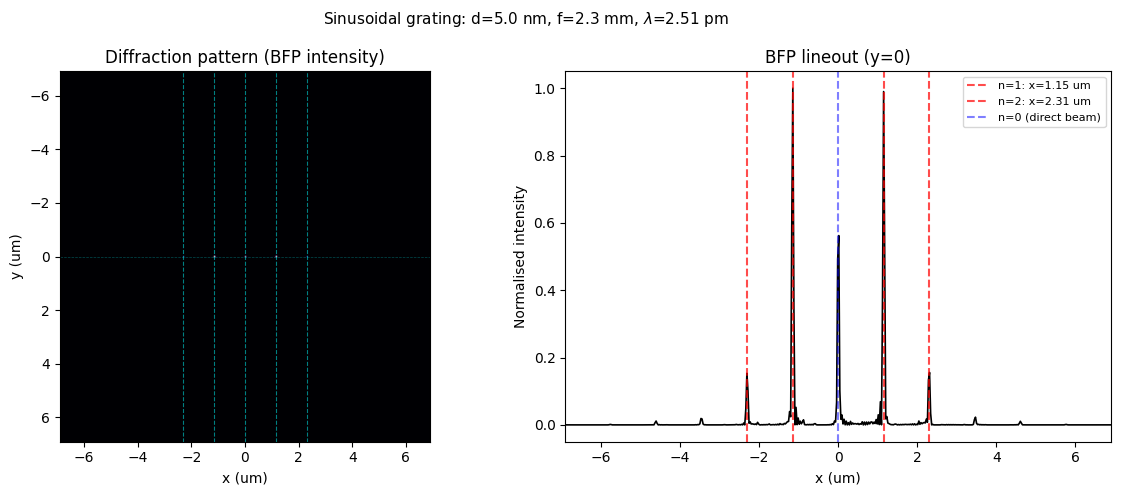

In [7]:
# Plot the diffraction pattern
ext = detector_bfp.extent
ext_um = [e * 1e6 for e in ext]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2D pattern
ax = axes[0]
ax.imshow(
    np.asarray(intensity_bfp),
    extent=ext_um,
    origin="lower",
    cmap="inferno",
)
for n in [-2, -1, 0, 1, 2]:
    ax.axvline(n * spot_spacing * 1e6, color="cyan", ls="--", alpha=0.5, lw=0.8)
ax.axhline(0, color="cyan", ls="--", alpha=0.3, lw=0.5)
ax.set_xlabel("x (um)")
ax.set_ylabel("y (um)")
ax.set_title("Diffraction pattern (BFP intensity)")

# 1D lineout through centre
ax = axes[1]
centre_row = n_det // 2
x_um = np.linspace(ext_um[0], ext_um[1], n_det)
lineout = np.asarray(intensity_bfp[centre_row, :])
ax.plot(x_um, lineout / lineout.max(), "k-", lw=1.2)
for n in [-2, -1, 1, 2]:
    ax.axvline(
        n * spot_spacing * 1e6,
        color="red",
        ls="--",
        alpha=0.7,
        label=f"n={n}: x={n * spot_spacing * 1e6:.2f} um" if n > 0 else None,
    )
ax.axvline(0, color="blue", ls="--", alpha=0.5, label="n=0 (direct beam)")
ax.set_xlabel("x (um)")
ax.set_ylabel("Normalised intensity")
ax.set_title("BFP lineout (y=0)")
ax.legend(fontsize=8)
ax.set_xlim(ext_um[0], ext_um[1])

fig.suptitle(
    f"Sinusoidal grating: d={grating_period*1e9:.1f} nm, "
    f"f={f*1e3:.1f} mm, $\\lambda$={wavelength*1e12:.2f} pm",
    fontsize=11,
)
plt.tight_layout()

### 1.6 Ray diagram: sample -> lens -> BFP

The ray diagram shows how individual Gaussian beams are deflected by the local
phase gradient of the sample. Each beam gets a kick proportional to
$\cos(2\pi x_0/d)$ at its position $x_0$. The lens then maps these angles to
positions in the BFP.

Note: the ray diagram shows a continuous fan of deflection angles -- the
discrete Bragg spots emerge from **coherent interference** in the intensity
pattern above, not from geometric ray focusing.

In [8]:
# Take a 1D slice of beams along y~0 for a cleaner ray diagram
y_vals = np.asarray(rays_after_sample.y)
mask = np.abs(y_vals) < waist
idx = np.where(mask)[0]

# Subsample if too many for clarity
if len(idx) > 80:
    idx = idx[::max(1, len(idx) // 80)]

rays_1d = jax.tree.map(lambda a: a[idx], rays_after_sample)
print(f"Plotting {len(idx)} beams in the ray diagram")

Plotting 80 beams in the ray diagram


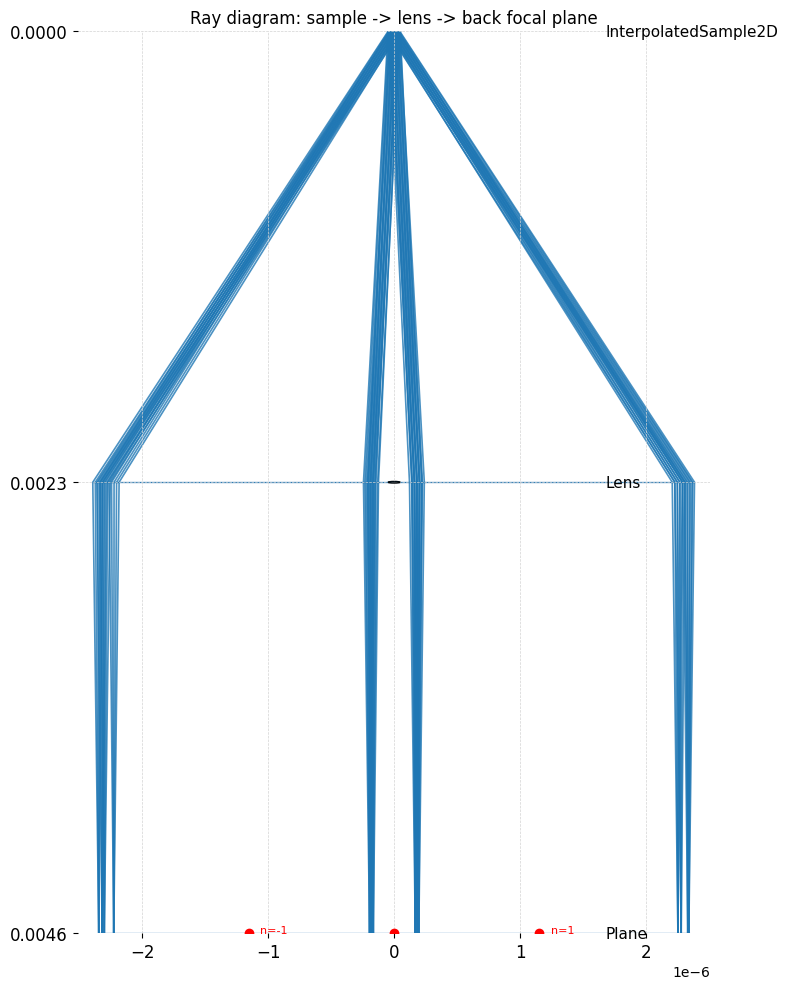

In [9]:
components_for_plot = [sample, lens, bfp_plane]

fig, ax = plot_model(
    components_for_plot,
    rays=rays_1d,
    plot_params=PlotParams(figsize=(8, 10)),
    band_mode="lines",
    ray_coordinate="x",
)

# Annotate expected Bragg spots
for n in [-1, 0, 1]:
    xn = n * spot_spacing
    ax.plot(xn, 2 * f, "ro", markersize=6, zorder=5)
    if n != 0:
        ax.annotate(
            f"n={n}",
            (xn, 2 * f),
            textcoords="offset points",
            xytext=(8, 0),
            fontsize=8,
            color="red",
        )

ax.set_title("Ray diagram: sample -> lens -> back focal plane")
plt.tight_layout()

### 1.7 Verify Bragg's law quantitatively

The peak positions in the BFP lineout should match $x_n = n\lambda f/d$.

In [ ]:
from scipy.signal import find_peaks

lineout_np = np.asarray(intensity_bfp[centre_row, :])
peaks, props = find_peaks(lineout_np, height=0.01 * lineout_np.max(), distance=5)

peak_positions_um = x_um[peaks]
peak_positions_um_sorted = np.sort(peak_positions_um)

print("Detected peaks (um):")
for p in peak_positions_um_sorted:
    print(f"  x = {p:+.3f} um")

print(f"\nExpected 1st-order spacing: {spot_spacing*1e6:.3f} um")
print(f"Bragg prediction: lambda*f/d = {spot_spacing*1e6:.3f} um")

### Summary

This notebook demonstrates that the Gaussian beam Taylor-expansion framework in TemGymCore correctly reproduces sinusoidal-grating diffraction:

1. Phase gradients from the sample deflect beams, with a transverse kick $\Delta\theta = \nabla(\phi/k)$ at each beam centre.
2. A lens converts those angles to positions in the back focal plane via $x_{\mathrm{BFP}} = f \cdot \theta$.
3. The coherent sum of all beams produces Bragg peaks at the expected positions $x_n = n\lambda f / d$.

The ray diagram shows the continuous fan of geometric deflections, while the detector intensity shows the additional effect of coherent interference that concentrates the signal into discrete diffraction orders.